# import

In [1]:
import sys
sys.path.append('..')
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
# from StatTools.generators.multi_scale_fractional_generator import MultiScaleFractionalGenerator
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import plotly.express as px
from nmot import NMOT

def gen_traj(frame_num: int, ants_num: int, frame_shape: tuple, margin:int = 10,
             hurst_move: float = 0.5, hurst_species: float = 0.5, 
             start_point = None):

    dx = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)
    dy = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)

    x = dx.cumsum(axis=0).round().astype(np.int32)
    y = dy.cumsum(axis=0).round().astype(np.int32)

    if start_point is None:
        start_x = np.random.randint(-margin, frame_shape[1] + margin, (ants_num,))
        start_y = np.random.randint(-margin, frame_shape[0] + margin, (ants_num,))
        start_point = np.stack([start_x, start_y], axis=1)

    trajectories = np.stack([x, y], axis=2)
    trajectories = trajectories + start_point

    return trajectories

In [2]:
class KalmanPredictor():
    def __init__(self):
        self.kf_states = {}

    def _init_kf(self, pos):
        kf = cv.KalmanFilter(dynamParams = 4, measureParams = 2)
        kf.measurementMatrix = np.array([[1,0,0,0],
                                         [0,1,0,0]], np.float32)

        kf.transitionMatrix = np.array([[1,0,1,0],
                                        [0,1,0,1], 
                                        [0,0,1,0], 
                                        [0,0,0,1]], np.float32)

        kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2 
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.statePost = np.array([[pos[0]], [pos[1]], [0], [0]], np.float32)

        return kf
    
    def predict_update(self, tracks):
        predictions = []
        for tid in range(tracks.shape[1]):
            kf = self.kf_states[tid]
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(tracks[0][tid][0])], [np.float32(tracks[0][tid][1])]], np.float32))
            predictions[tid] = [*x_pred, *y_pred]
            
        return predictions


# few tracks

In [83]:
np.random.seed(42)
hurst_move = 0.5
traj = gen_traj(frame_num=10000, 
                ants_num=1, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = hurst_move,
                hurst_species = 0.5, 
                start_point = None)


In [84]:
kp = KalmanPredictor()
kf_dict = {}
for tid in range(traj.shape[1]):
    kf_dict[tid] = kp._init_kf(traj[0, tid])

from collections import defaultdict
predictions = defaultdict(list)
for tid in range(traj.shape[1]):
    
    kf = kf_dict[tid]
    for detections in traj[1:, tid, :]:
        x_pred, y_pred, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
        predictions[tid].append([*x_pred, *y_pred])
        
kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))

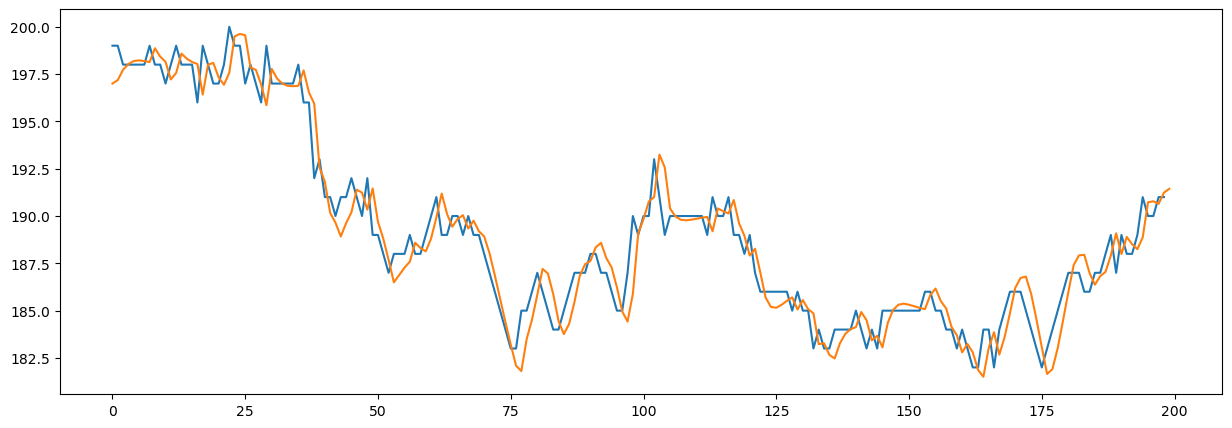

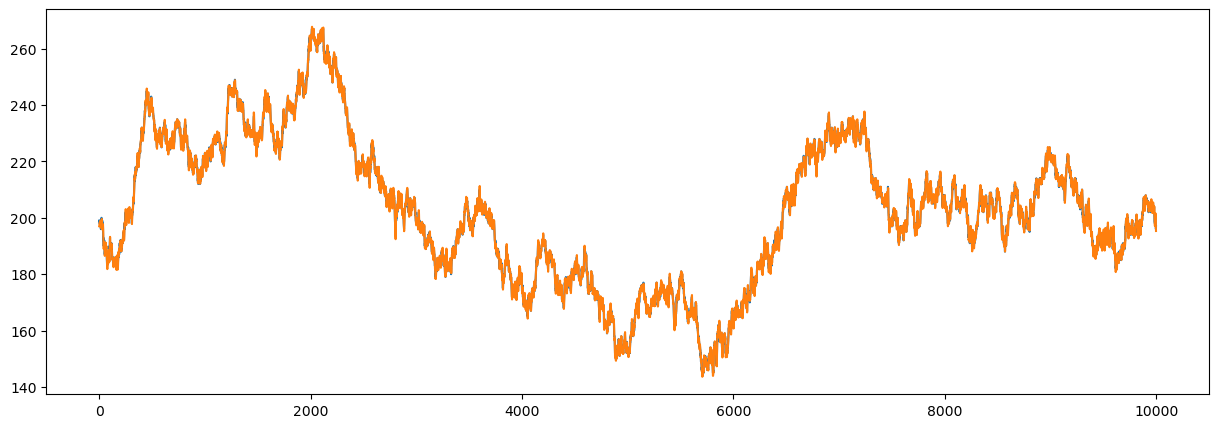

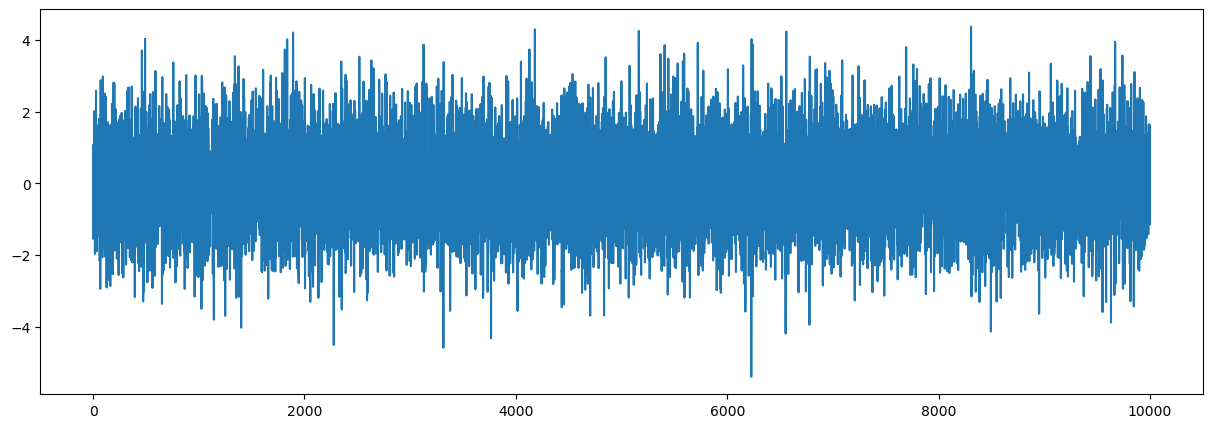

In [85]:
plt.figure(figsize=(15, 5))
plt.plot(traj[1:200,0,0], label=f'fBm H:{hurst_move}')
plt.plot(kalman_preds[:200,0,0], label=f'fBm H:{hurst_move}')
plt.savefig(f'../data/artifacts/fgn_{hurst_move}_kalman_preds_lowscale.svg')
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(traj[1:,0,0])
plt.plot(kalman_preds[:,0,0])
plt.savefig(f'../data/artifacts/fgn_{hurst_move}_kalman_preds_highscale.svg')
plt.show()

fig, ax = plt.subplots()
fig.set_size_inches((15, 5))
# ax[0].plot(traj[1:,0,0]-kalman_preds[:,0,0])
ax.plot(traj[1:,0,1]-kalman_preds[:,0,1])
plt.savefig(f'../data/artifacts/fgn_{hurst_move}_kalman_error.svg')
plt.show()


In [78]:

rmse = np.sqrt(np.mean((traj[1:]-kalman_preds)**2))
mse = np.mean((traj[1:]-kalman_preds)**2)
print(f'{rmse=:.4f}')
print(f'{mse=:.4f}')

rmse=0.8700
mse=0.7570


# rmse vs hurst

In [3]:
hurst_dict = {}
for hurst in np.arange(0.1, 2.0, 0.1):
    np.random.seed(42)
    traj = gen_traj(frame_num=1000, 
                    ants_num=300, 
                    frame_shape=(500, 500), 
                    margin = -10,
                    hurst_move = hurst,
                    hurst_species = 0.5, 
                    start_point = None)
    kp = KalmanPredictor()
    kf_dict = {}
    for tid in range(traj.shape[1]):
        kf_dict[tid] = kp._init_kf(traj[0, tid])

    from collections import defaultdict
    predictions = defaultdict(list)
    for tid in range(traj.shape[1]):
        
        kf = kf_dict[tid]
        for detections in traj[1:, tid, :]:
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
            predictions[tid].append([*x_pred, *y_pred])
            
    kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))
    rmse = np.mean(np.sqrt(np.mean((traj[1:]-kalman_preds)**2, axis=0)), axis=1)
    hurst_dict[hurst.round(1)] = rmse

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in reciprocal
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))


In [4]:
hurst_df = pd.DataFrame(hurst_dict)

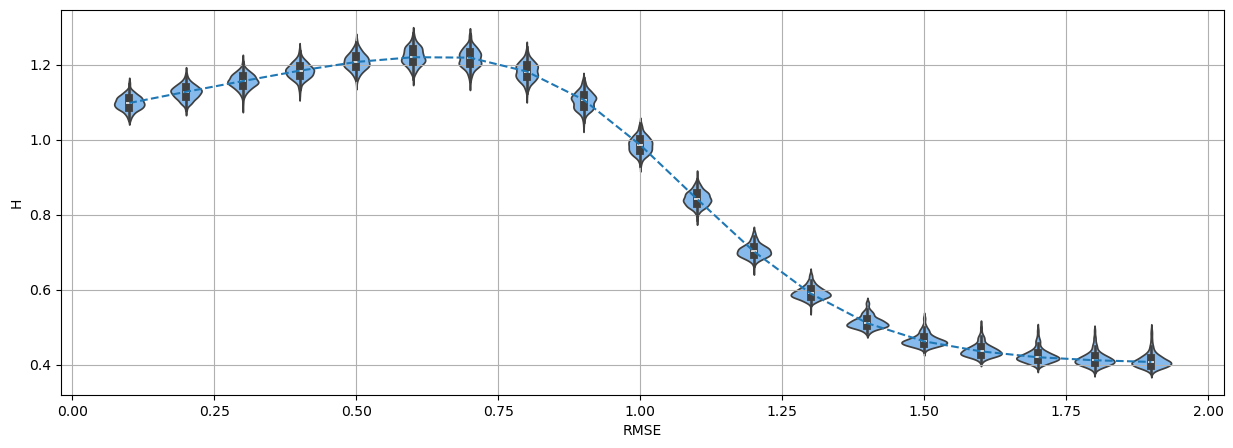

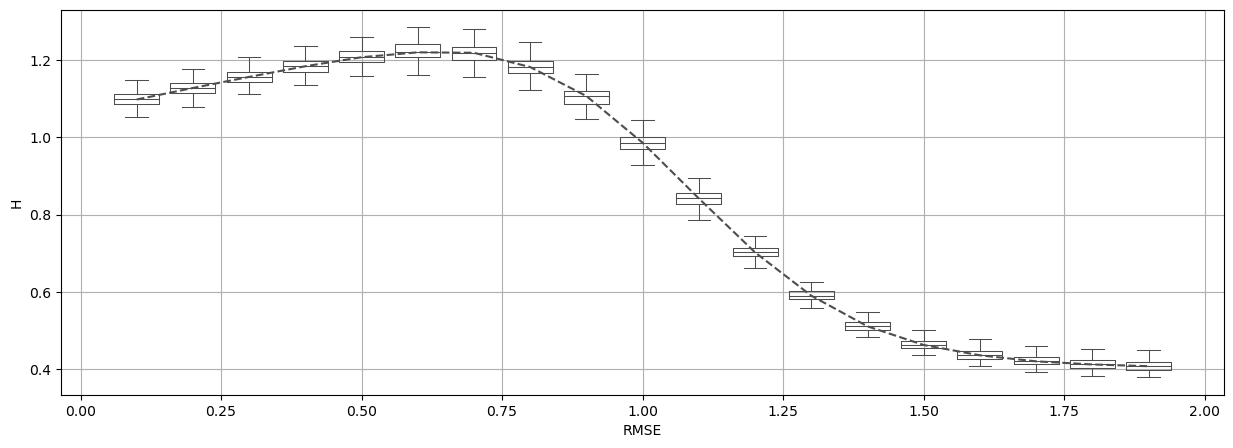

In [40]:
# plt.figure(figsize = (15, 5))
# sns.kdeplot(hurst_df, palette='viridis')
# plt.xlabel('RMSE')
# plt.ylabel('')
# plt.show()

plt.figure(figsize = (15, 5))
sns.violinplot(hurst_df, native_scale=True, color='xkcd:sky blue')
plt.plot(hurst_df.median(), linestyle = '--')
plt.xlabel('RMSE')
plt.ylabel('H')

plt.grid()

fig_box = plt.figure(figsize = (15, 5))
sns.boxplot(hurst_df, native_scale=True, color='.3', fill=False, linewidth=.75, showfliers=False)
plt.plot(hurst_df.median(), linestyle = '--', color='.3')
plt.xlabel('RMSE')
plt.ylabel('H')
plt.grid()
plt.savefig('../data/artifacts/kalman_cv_vs_fgn_H_value.svg')

# tracker debug

In [3]:
def track(
    input_path: str,
    output_path: str = "tracked_output.mp4",
    csv_path: str = "tracks.csv",
    imshow=True,
    roi=None,
    dist2Threshold=50,
    knn_history = 100,
    pred_head = 'kalman',
    warmup_frames = 50,
    kasdin_hurst=1.2
):
    if pred_head=='zero': pred_head=None
    
    cap = cv.VideoCapture(input_path)

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {input_path}")

    fps = cap.get(cv.CAP_PROP_FPS)
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    if output_path is not None:
        fourcc = cv.VideoWriter_fourcc(*"mp4v")
        writer = cv.VideoWriter(output_path, fourcc, fps, (width, height))

    tracker = NMOT(
        warmup_frames=warmup_frames,
        dist2Threshold=dist2Threshold,
        knn_history=knn_history,
        min_area=8,
        max_area=80,
        max_match_dist=25,
        max_missed=12,
        pred_head=pred_head,
        roi=roi,
        kasdin_hurst=kasdin_hurst
    )

    while True:
        ok, frame = cap.read()

        if not ok:
            break

        vis, mask, active_tracks = tracker.update(frame)
        if output_path is not None: 
            writer.write(vis)

        if imshow:
            # cv2.imshow('frame', frame)
            fig, ax = plt.subplots(nrows=2)
            fig.set_size_inches((20, 10))
            
            ax[0].imshow(vis)
            ax[1].imshow(mask)
            
            plt.show()
            
            clear_output(wait=True)
            if cv.waitKey(1) & 0xFF == 27:
                cv.destroyAllWindows()
                if output_path:
                    writer.release()
                break

    cap.release()
    if output_path is not None: 
        writer.release()
    cv.destroyAllWindows()
    if csv_path:
        df = tracker.save_tracks(csv_path)

    # return df

In [ ]:
# kasdin_hurst = 1.0]
for seed in np.arange(1, 50, 1, dtype=int):
      # for hurst in [0.8, 0.9, 1.0, 1.1, 1.2, 1.3]:
      track(input_path=f'../data/synth_collision_gt/gt_{seed}.mp4',
            output_path=None,
            csv_path=f'../data/synth_collision_tracked/tracked_kasdin_kalman_{seed}.csv',
            dist2Threshold=200,
            knn_history = 200,
            imshow=False,
            pred_head='kalman',
            warmup_frames=30,
            kasdin_hurst=1.2)

In [ ]:
# from eval import evaluate_mot
# def eval(gt_path, pred_path, warmup_frames:int, alpha_dist = 5.0):
    
    
#     gt = pd.read_csv(gt_path)
#     pred = pd.read_csv(pred_path)

#     gt = gt.rename(columns={'ant_id':'track_id'})
#     gt = gt[gt.frame >= warmup_frames]

#     summary, accumulator = evaluate_mot(gt, pred, distance_threshold=alpha_dist)

#     return summary

# pred_head_result = {}
# for hurst in [0.8, 0.9, 1.0, 1.1, 1.2, 1.3]:
#     summary = eval(gt_path = '../data/synth_collision_gt/gt_1.csv',
#                    pred_path = f'../data/synth_collision_tracked/tracked_kasdin{hurst}_kalman_1.csv',
#                    warmup_frames=30,
#                    alpha_dist=5.0)
#     pred_head_result[str(hurst)] = summary.T

In [ ]:
from eval import evaluate_mot
def eval(gt_path, pred_path, warmup_frames:int, alpha_dist = 5.0):
    
    
    gt = pd.read_csv(gt_path)
    pred = pd.read_csv(pred_path)

    gt = gt.rename(columns={'ant_id':'track_id'})
    gt = gt[gt.frame >= warmup_frames]

    summary, accumulator = evaluate_mot(gt, pred, distance_threshold=alpha_dist)

    return summary

pred_head_result = []
for seed in np.arange(1, 50, 1, dtype=int):
    summary = eval(gt_path = f'../data/synth_collision_gt/gt_{seed}.csv',
                   pred_path = f'../data/synth_collision_tracked/tracked_kasdin_kalman_{seed}.csv',
                   warmup_frames=30,
                   alpha_dist=5.0)
    pred_head_result.append(summary.T)

In [ ]:
kalman_kasdin_dict = dict(zip(np.arange(1, 50, 1, dtype=int), pred_head_result))

In [ ]:
kalman_kasdin_metrics = pd.concat(kalman_kasdin_dict).reset_index()
kalman_kasdin_metrics.columns = ['seed', 'metric', 'value']

In [ ]:
# kalman_kasdin_metrics.to_pickle('../data/kalman_kasdin_metrics.pkl')

In [ ]:
# id_family = ['idf1', 'idp', 'idr']
# mota_family = ['motp', 'mota']
# hota_family = ['deta_alpha', 'assa_alpha', 'hota_alpha']
target_metrics = ['motp', 'mota', 'idf1', 'idp', 'idr', 'deta_alpha', 'assa_alpha', 'hota_alpha']
# fig, ax = plt.subplots(nrows = 3)
# fig.set_size_inches((15, 10))
# sns.boxplot(kasdin_kalman_metrics.loc[kasdin_kalman_metrics.metric.isin(id_family)], y='value', x='metric', hue='hurst', orient='v', width=0.25, ax=ax[0])
# sns.boxplot(kasdin_kalman_metrics.loc[kasdin_kalman_metrics.metric.isin(mota_family)], y='value', x='metric', hue='hurst', orient='v', width=0.25, ax=ax[1])
# sns.boxplot(kasdin_kalman_metrics.loc[kasdin_kalman_metrics.metric.isin(hota_family)], y='value', x='metric', hue='hurst', orient='v', width=0.25, ax=ax[2])

ncols = 4
nrows = -(-len(target_metrics)//ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
axes = axes.flatten()
fig.set_size_inches((15, 10))
for idx, ax in enumerate(axes):

    ax.grid()
plt.legend()
plt.tight_layout()
plt.show()